In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ROOT_DIR = Path.cwd() 
orFILE_PATH = ROOT_DIR / 'data' / 'orders.csv'
saFILE_PATH = ROOT_DIR / 'data' / 'customers.csv'
suFILE_PATH = ROOT_DIR/ 'data' / 'superstoreSales.csv'

orders = pd.read_csv(orFILE_PATH)
sales = pd.read_csv(saFILE_PATH)
supersales = pd.read_csv(suFILE_PATH, encoding='latin1')


Merge. Using the provided orders.csv and customers.csv , join them on customer_id so
each order shows the customer's name and city, then find which customer spent the
most ( quantity * price summed per name).

In [8]:

merged = pd.merge(orders, sales, on='customer_id', how='left')
merged['total'] = merged['price'] * merged['quantity']
merged = merged.sort_values(by='total', ascending=False)
print(merged)

   order_id customer_id         product  quantity  price  order_date  \
10    O1011        C005    Office Chair         2  145.0  2024-05-06   
9     O1010        C001         Monitor         1  220.0  2024-04-18   
4     O1005        C004         Monitor         1  220.0  2024-02-19   
14    O1015        C006         Monitor         1  220.0  2024-06-29   
5     O1006        C005        Keyboard         4   45.0  2024-03-02   
1     O1002        C003    Office Chair         1  145.0  2024-01-22   
13    O1014        C002       Desk Lamp         3   28.0  2024-06-15   
2     O1003        C002    Laptop Stand         2   35.0  2024-02-03   
6     O1007        C003       Desk Lamp         2   28.0  2024-03-14   
12    O1013        C003        Keyboard         1   45.0  2024-06-01   
3     O1004        C001     USB-C Cable         5    8.0  2024-02-11   
0     O1001        C001  Wireless Mouse         3   12.5  2024-01-15   
7     O1008        C002    Laptop Stand         1   35.0  2024-0

Pivot. Using Superstore Sales, build a pivot table of average Sales with rows =
Region and columns = Product Category .

In [10]:
pivot = merged.pivot_table(index='city', columns='segment', values='price', aggfunc='mean')
print(pivot)

segment       Consumer  Corporate  Home Office
city                                          
Biratnagar         NaN  95.000000          NaN
Kathmandu    80.166667        NaN        114.0
Lalitpur     72.666667        NaN          NaN
Pokhara     116.250000  32.666667          NaN


Charts. From Superstore, make a bar chart of total sales by region and a line chart of
total sales by month, each with a title and labels.

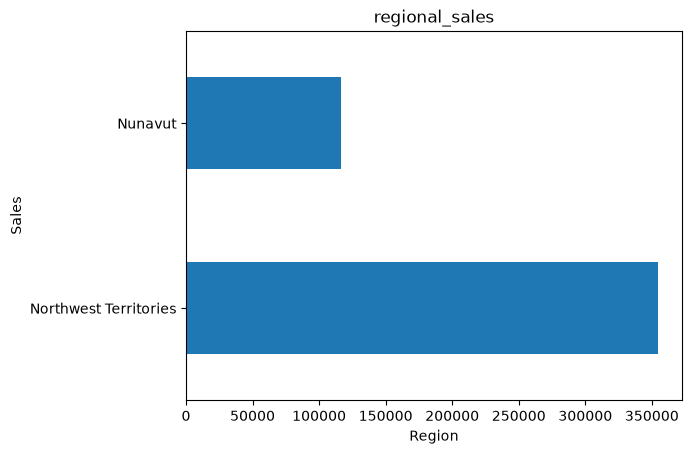

In [20]:
regional_sales = supersales.groupby('Region')['Sales'].sum()

regional_sales.plot(kind='barh', x='Region', y='Sales')

plt.xlabel('Region')
plt.ylabel('Sales')
plt.title('regional_sales')

plt.show()

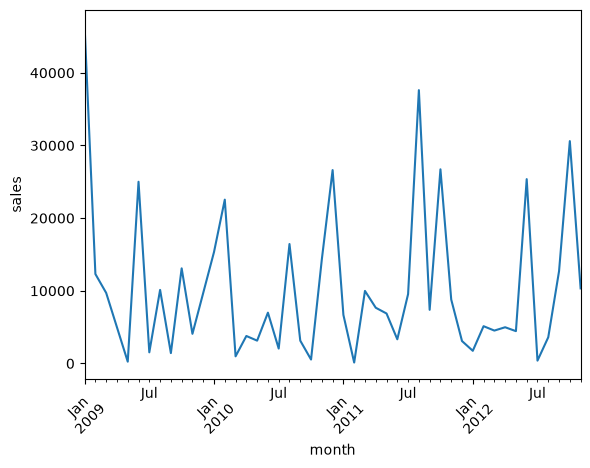

In [ ]:
supersales['Order Date'] = pd.to_datetime(supersales['Order Date'])
supersales['Month'] = supersales['Order Date'].dt.to_period('M')
sales_month = supersales.groupby('Month')['Sales'].sum()

sales_month.plot(kind='line', x='Order Date', y='Sales')
plt.xticks(rotation=45)
plt.xlabel('month')
plt.ylabel('sales')
plt.show()



Export. Save one of your summary tables to summary.csv

In [22]:
sales_month.to_csv('summary.csv')